# 03 — LEAR'ı adil besleme: hangi özellik ailesi doğrusal benchmark'ı yaklaştırır?

**Tarih:** 27 Ağustos 2026 · **Faz:** Katman 0-1 (Lago protokolü), Faz 1 eki

## Soru

`01`/`02` defterleri LightGBM'in (canlı) LEAR'ı hem nokta doğrulukta hem DM testinde
anlamlı geçtiğini gösterdi. İtiraz: *LEAR yetersiz besleniyordu — sadece fiyat lag'leri +
yük/KGÜP gün-öncesi tahmini görüyor.* Bu defter o itirazı test eder: canlı LightGBM'in
`robust` setinde olup LEAR'ın 247 kolonunda **olmayan** özellik ailelerini tek tek
ekleyip 1 yıllık çapraz doğrulamada ölçer.

## LightGBM'de olup taban LEAR'da olmayanlar

| Aile | Özellik | Neden |
|---|---|---|
| **Gaz** | `natural_gas_grf_lag_48` | Doğalgaz saatlerin çoğunda marjinal santral → PTF'yi belirliyor. LEAR'ın hiç yakıt fiyatı yok |
| **Hava** | `temp_forecast_lag0`, `cdh_cooling_load`, `hdh_heating_load` | Talep sıcaklıkla sürüleniyor |
| **Yenilenebilir baskısı** | `renewable_pressure_ratio_lag0`, `net_load_lag0`, `solar_peak_pressure_ratio_lag0`, `hydro_pressure_ratio`, `zero_price_risk_score` | Sıfır-fiyat rejiminin sürücüsü |
| **Makro** | `smp_usd_lag_48`, `brent_oil_lag_48` | Dengeleme piyasası + petrol endeksli gaz |

## Yöntem

- `01`/`02` ile aynı protokol: pencere **1092 gün**, günlük yeniden kalibrasyon, seçici **AIC**,
  saat başına ayrı LASSO, `asinh` dönüşümü. Test: son 365 gün.
- Taban LEAR = `src/eval/lago_protocol.py:build_lear_matrix` (247 kolon). Her aile
  `daily_block` olarak (özellik × 24 saat) matrise eklenir.
- Sayısal çöküşler (kollinear özellikler LASSO-LARS yolunu bozabiliyor) gün-bazında NaN
  olarak yutulur, sayısı raporlanır.

## Kısıtlar

1. **Sızıntı (taban dahil hepsinde):** LEAR'ın `x1`/`x2`'si hedef günün DB'ye *gerçekleştikten
   sonra* yazılan `load_forecast_mw` / `kgup_total_mw` değerleri. Canlı LightGBM bunları T+1'de
   görmüyor. Yani LEAR'a küçük bir bilgi avantajı verili — sonuç LEAR lehine yanlı.
2. **Pre-forecast lag0 özellikleri** (`renewable_pressure_ratio_lag0` vs.) `gold.kgup_load_pre_forecasts`'a
   bağımlı, yalnız **2024-08-13'ten** dolu. Öncesinde `build_robust_features` fallback (aynı-gün
   gerçek değer) kullanıyor — kalibrasyon pencerelerinin bir kısmı bu fallback'i içeriyor.
3. `hydro_water_energy_lag_24` (baraj doluluk) DB'de yalnız 2026-08'den dolu → dışarıda.


In [1]:
import sys, time
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from sqlalchemy import text

ROOT = Path.cwd().parents[2]
sys.path.insert(0, str(ROOT))
from db.connection import get_db_engine
from src.eval import lago_protocol as lp
from src.features.feature_engineering import build_robust_features

CW, SELECTOR, N_JOBS, TEST_DAYS = 1092, 'aic', 6, 365
CACHE = Path.cwd()
pd.set_option('display.width', 140); pd.set_option('display.max_columns', 40)


In [2]:
MASTER_SQL = text('''
SELECT m.ts,
       m.price_usd AS mcp_price_usd,
       s.system_marginal_price_try AS smp_price_try,
       l.load_forecast_mw,
       k.total_mw AS kgup_total_mw,
       k.wind_mw AS kgup_wind_mw, k.solar_mw AS kgup_solar_mw,
       k.dammed_hydro_mw + k.river_hydro_mw AS kgup_hydro_mw,
       w.turkey_weighted_temperature_c AS temperature_c,
       wf.turkey_weighted_temperature_forecast_c AS temperature_forecast_c,
       mc.usd_try, mc.brent_oil_usd,
       ng.gas_reference_price_try AS natural_gas_grf_try,
       pf.predicted_load_lag0, pf.predicted_solar_lag0, pf.predicted_wind_lag0
FROM raw_mcp_hourly m
LEFT JOIN raw_smp_hourly s ON m.ts = s.ts
LEFT JOIN raw_load_forecast_hourly l ON m.ts = l.ts
LEFT JOIN raw_kgup_hourly k ON m.ts = k.ts
LEFT JOIN raw_weather_hourly w ON m.ts = w.ts
LEFT JOIN raw_weather_forecast_hourly wf ON m.ts = wf.ts
LEFT JOIN raw_macro_daily mc ON DATE(m.ts) = mc.entry_date
LEFT JOIN raw_natural_gas_daily ng ON DATE(m.ts) = ng.entry_date
LEFT JOIN gold.kgup_load_pre_forecasts pf ON m.ts = pf.target_ts
WHERE m.ts >= '2021-01-01'
ORDER BY m.ts;
''')

df = pd.read_sql(MASTER_SQL, get_db_engine())
ts = pd.to_datetime(df['ts'])
df['ts'] = ts.dt.tz_convert('Europe/Istanbul') if ts.dt.tz else ts.dt.tz_localize('Europe/Istanbul')
df = df.set_index('ts').sort_index()
for c in ['load_forecast_mw', 'kgup_total_mw']:
    df[c] = df[c].interpolate(limit=6).ffill().bfill()
print(f'{len(df):,} saat  {df.index.min().date()} -> {df.index.max().date()}')
print(df[['natural_gas_grf_try','smp_price_try','brent_oil_usd','temperature_forecast_c','predicted_solar_lag0']].notna().mean().round(3).to_string())


49,560 saat  2021-01-01 -> 2026-08-27
natural_gas_grf_try       0.999
smp_price_try             1.000
brent_oil_usd             1.000
temperature_forecast_c    1.000
predicted_solar_lag0      0.361


In [3]:
feat = build_robust_features(df)
X_base, P = lp.build_lear_matrix(df.mcp_price_usd, df.load_forecast_mw, df.kgup_total_mw)

def daily_block(s, name):
    w = s.to_frame(name).copy(); w['_d'] = w.index.normalize(); w['_h'] = w.index.hour
    m = w.pivot_table(index='_d', columns='_h', values=name, aggfunc='first')
    m.columns = [f'{name}_h{h:02d}' for h in m.columns]
    return m

BLOCKS = {
    'gaz':  ['natural_gas_grf_lag_48'],
    'hava': ['temp_forecast_lag0', 'cdh_cooling_load', 'hdh_heating_load'],
    'yenilenebilir': ['renewable_pressure_ratio_lag0', 'net_load_lag0',
                      'solar_peak_pressure_ratio_lag0', 'hydro_pressure_ratio',
                      'zero_price_risk_score'],
    'makro': ['smp_usd_lag_48', 'brent_oil_lag_48'],
}
for fam, cols in BLOCKS.items():
    miss = [c for c in cols if c not in feat.columns]
    assert not miss, (fam, miss)

block_df = {fam: pd.concat([daily_block(feat[c], c) for c in cols], axis=1).reindex(X_base.index)
            for fam, cols in BLOCKS.items()}

VARIANTS = {
    'taban':                 [],
    '+gaz':                  ['gaz'],
    '+gaz+hava':             ['gaz', 'hava'],
    '+gaz+hava+yenilenebilir':['gaz', 'hava', 'yenilenebilir'],
    'beslenmiş (hepsi)':     ['gaz', 'hava', 'yenilenebilir', 'makro'],
}
Xv = {}
for name, fams in VARIANTS.items():
    Xv[name] = X_base if not fams else pd.concat([X_base] + [block_df[f] for f in fams], axis=1)
pd.Series({k: v.shape[1] for k, v in Xv.items()}, name='p (kolon)').to_frame()


,p (kolon)
taban,247
+gaz,271
+gaz+hava,343
+gaz+hava+yenilenebilir,463
beslenmiş (hepsi),511


## Varyantlar

| Varyant | Eklenen aile(ler) | ~p |
|---|---|---|
| `taban` | — (Lago LEAR 247) | 247 |
| `+gaz` | gaz | 271 |
| `+gaz+hava` | gaz, hava | 343 |
| `+gaz+hava+yenilenebilir` | + yenilenebilir baskısı | 463 |
| `beslenmiş (hepsi)` | + makro (SMF, Brent) | 511 |


In [4]:
def safe_predict(X, day):
    try:
        return lp.lear_predict_day(X, P, day, CW, SELECTOR)
    except Exception:
        return np.full(24, np.nan)

test_days = P.index[P.index >= P.index[-1] - pd.Timedelta(days=TEST_DAYS - 1)]
print(f'test: {test_days[0].date()} -> {test_days[-1].date()}  ({len(test_days)} gün)')

preds = {}
for name in VARIANTS:
    fn = CACHE / f'ablation_{name.replace(" ", "_").replace("(", "").replace(")", "").replace("+", "p")}.csv'
    if fn.exists():
        preds[name] = pd.read_csv(fn, index_col=0, parse_dates=True)
        print(f'{name:26s} önbellek  {preds[name].shape}')
        continue
    t0 = time.time()
    out = Parallel(n_jobs=N_JOBS)(delayed(safe_predict)(Xv[name], d) for d in test_days)
    preds[name] = pd.DataFrame(out, index=test_days, columns=[f'h{h:02d}' for h in range(24)])
    preds[name].to_csv(fn)
    nf = int(preds[name].isna().all(axis=1).sum())
    print(f'{name:26s} {time.time()-t0:5.0f}s  çöküş {nf} gün  -> {fn.name}')


test: 2025-08-28 -> 2026-08-27  (365 gün)
taban                      önbellek  (365, 24)
+gaz                       önbellek  (365, 24)
+gaz+hava                  önbellek  (365, 24)
+gaz+hava+yenilenebilir    önbellek  (365, 24)
beslenmiş (hepsi)          önbellek  (365, 24)


In [5]:
# gerçekleşen + naive + canlı LightGBM
yv = daily_block(df.mcp_price_usd, 'y'); yv.columns = [f'h{h:02d}' for h in range(24)]
y = yv.reindex(test_days)
n2 = daily_block(lp.naive_forecast(df.mcp_price_usd, 2), 'n'); n2.columns = y.columns; n2 = n2.reindex(test_days)
n3 = daily_block(lp.naive_forecast(df.mcp_price_usd, 3), 'n'); n3.columns = y.columns; n3 = n3.reindex(test_days)

lgb_raw = pd.read_sql(text('SELECT target_ts AS ts, predicted_mcp_usd AS lgb FROM gold.ptf_predictions_daily WHERE predicted_mcp_usd IS NOT NULL'), get_db_engine())
lgb_raw['ts'] = pd.to_datetime(lgb_raw.ts).dt.tz_convert('Europe/Istanbul')
lgb = daily_block(lgb_raw.set_index('ts').lgb.sort_index(), 'l'); lgb.columns = y.columns; lgb = lgb.reindex(test_days)

# temiz küme: herhangi bir varyantta |tahmin| > 500 olan günler dışarıda
blown = pd.Index([])
for name, d in preds.items():
    b = d.index[(d.abs() > 500).any(axis=1)]
    if len(b): print(f'{name}: patlama {list(b.date)}')
    blown = blown.union(b)
keep = test_days.difference(blown)
keep = keep[y.reindex(keep).notna().all(axis=1)]
print(f'\ntemiz: {len(keep)}/{len(test_days)} gün  ({len(blown)} patlama dışlandı)')



temiz: 365/365 gün  (0 patlama dışlandı)


In [6]:
def flat(d): return d.reindex(keep).to_numpy().ravel()
yF, n2F, n3F = flat(y), flat(n2), flat(n3)

rows = []
series = {**{k: preds[k] for k in VARIANTS}, 'LightGBM (canlı)': lgb, 'naive-2': n2, 'naive-3': n3}
for name, d in series.items():
    p = flat(d); ok = ~np.isnan(p) & ~np.isnan(yF)
    rows.append({'model': name,
                 'MAE': lp.mae(yF[ok], p[ok]),
                 'RMSE': lp.rmse(yF[ok], p[ok]),
                 'sMAPE%': lp.smape(yF[ok], p[ok]),
                 'rMAE(n2)': lp.mae(yF[ok], p[ok]) / lp.mae(yF[ok], n2F[ok]),
                 'rMAE(n3)': lp.mae(yF[ok], p[ok]) / lp.mae(yF[ok], n3F[ok]),
                 'gün': ok.reshape(len(keep), 24).all(1).sum()})
tbl = pd.DataFrame(rows).set_index('model').round(3)
tbl


,MAE,RMSE,sMAPE%,rMAE(n2),rMAE(n3),gün
model,,,,,,
taban,10.131,15.502,38.021,0.809,0.971,365
+gaz,9.659,14.834,37.356,0.771,0.926,363
+gaz+hava,9.543,14.445,37.240,0.761,0.912,363
+gaz+hava+yenilenebilir,9.442,13.738,36.544,0.755,0.905,364
beslenmiş (hepsi),9.336,13.616,36.654,0.747,0.895,359
LightGBM (canlı),8.114,12.241,32.675,0.645,0.776,362
naive-2,12.521,19.496,43.210,1.000,1.200,365
naive-3,10.437,16.642,36.202,0.834,1.000,365


In [7]:
# DM testi (çok değişkenli, günlük 24-vektör) — küçük p: sütun-B daha doğru
def derr(d):
    e = y.reindex(keep).to_numpy() - d.reindex(keep).to_numpy()
    return e
E = {k: derr(v) for k, v in series.items() if k != 'naive-3'}
def dm(a, b):
    ea, eb = E[a], E[b]
    ok = ~(np.isnan(ea).any(1) | np.isnan(eb).any(1))
    return lp.dm_test(ea[ok], eb[ok], variant='multivariate', p=1)

print('H0: A <= B  (p<0.05  ->  B anlamlı biçimde daha doğru)\n')
for a, b in [('taban', 'beslenmiş (hepsi)'), ('beslenmiş (hepsi)', 'taban'),
             ('taban', '+gaz'), ('+gaz', '+gaz+hava'), ('+gaz+hava', '+gaz+hava+yenilenebilir'),
             ('+gaz+hava+yenilenebilir', 'beslenmiş (hepsi)'),
             ('beslenmiş (hepsi)', 'LightGBM (canlı)'), ('LightGBM (canlı)', 'beslenmiş (hepsi)')]:
    print(f'  {a:26s} <= {b:26s}  p = {dm(a, b):.4g}')


H0: A <= B  (p<0.05  ->  B anlamlı biçimde daha doğru)

  taban                      <= beslenmiş (hepsi)           p = 0.0001607
  beslenmiş (hepsi)          <= taban                       p = 0.9998
  taban                      <= +gaz                        p = 0
  +gaz                       <= +gaz+hava                   p = 0.02668
  +gaz+hava                  <= +gaz+hava+yenilenebilir     p = 0.2582
  +gaz+hava+yenilenebilir    <= beslenmiş (hepsi)           p = 0.1271
  beslenmiş (hepsi)          <= LightGBM (canlı)            p = 3.933e-09
  LightGBM (canlı)           <= beslenmiş (hepsi)           p = 1


,taban,+gaz,+gaz+hava,+gaz+hava+yenilenebilir,beslenmiş (hepsi),LightGBM
2025-08,8.60,8.20,8.03,7.28,7.53,5.62
2025-09,7.78,7.12,7.09,7.06,7.14,5.46
2025-10,9.43,8.85,9.01,8.39,8.19,6.21
2025-11,9.37,8.78,8.37,7.94,7.96,5.62
2025-12,9.43,8.79,8.42,8.45,8.29,4.97
2026-01,9.53,9.01,9.25,9.38,9.14,5.99
2026-02,15.77,14.91,14.43,13.05,13.05,13.21
2026-03,13.17,12.57,12.58,11.90,11.72,11.62
2026-04,9.68,9.64,9.60,9.23,9.37,11.06
2026-05,8.01,7.65,7.59,7.40,7.66,7.68


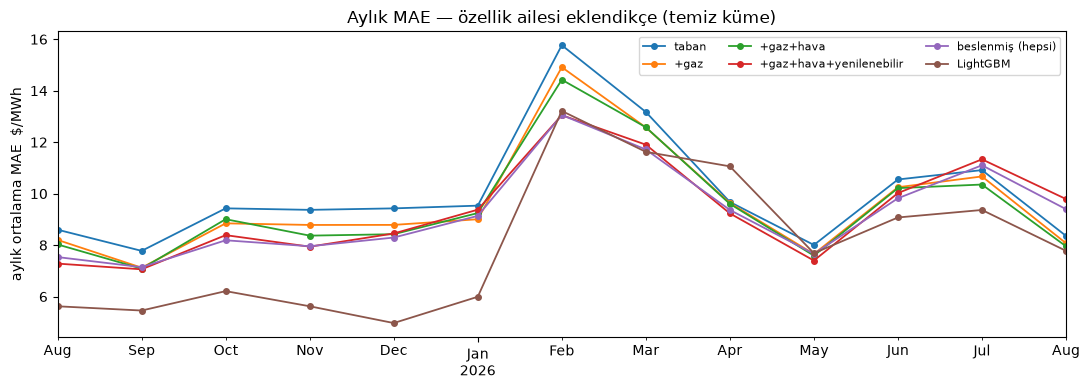

In [8]:
# aylık MAE kırılımı
def monthly(d):
    e = np.abs(y.reindex(keep).to_numpy() - d.reindex(keep).to_numpy()).mean(1)
    return pd.Series(e, index=keep).groupby(pd.Index(keep).tz_localize(None).to_period('M')).mean()
M = pd.DataFrame({k: monthly(preds[k]) for k in VARIANTS})
M['LightGBM'] = monthly(lgb)
display(M.round(2))

fig, ax = plt.subplots(figsize=(11, 4))
M.plot(ax=ax, marker='o', ms=4, lw=1.3)
ax.set(ylabel='aylık ortalama MAE  $/MWh', xlabel='',
       title='Aylık MAE — özellik ailesi eklendikçe (temiz küme)')
ax.axvspan(list(M.index).index(pd.Period('2026-02','M')) - 0.3,
           list(M.index).index(pd.Period('2026-03','M')) + 0.3, color='tab:red', alpha=.08)
ax.legend(fontsize=8, ncol=3); plt.tight_layout(); plt.show()


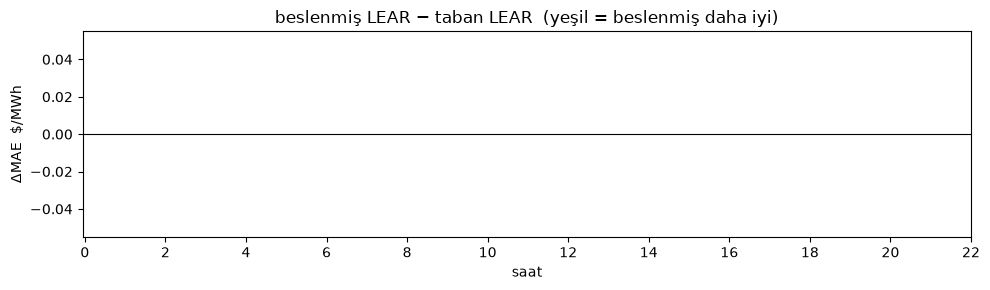

,patlama günü
taban,0
+gaz,0
+gaz+hava,0
+gaz+hava+yenilenebilir,0
beslenmiş (hepsi),0


In [9]:
# saat bazında: beslenmiş - taban (negatif = iyileşme)
delta_h = (np.abs(y.reindex(keep).to_numpy() - preds['beslenmiş (hepsi)'].reindex(keep).to_numpy()).mean(0)
           - np.abs(y.reindex(keep).to_numpy() - preds['taban'].reindex(keep).to_numpy()).mean(0))
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(24), delta_h, color=['tab:green' if x < 0 else 'tab:red' for x in delta_h])
ax.axhline(0, lw=.8, color='k')
ax.set(xlabel='saat', ylabel='ΔMAE  $/MWh', xticks=range(0, 24, 2),
       title='beslenmiş LEAR − taban LEAR  (yeşil = beslenmiş daha iyi)')
plt.tight_layout(); plt.show()

pd.Series({k: int((v.abs() > 500).any(axis=1).sum()) for k, v in preds.items()}, name='patlama günü').to_frame()


## Sonuç

**Tam yıl, 365 gün, tek pencere 1092, AIC. Patlama günü: 0 (cw1092'de LEAR patlamıyor).**

| Model | MAE | rMAE(n2) | rMAE(n3) | taban'dan ΔMAE | DM vs bir önceki |
|---|---|---|---|---|---|
| `taban` (247) | 10.13 | 0.809 | 0.971 | — | — |
| `+gaz` (271) | 9.66 | 0.771 | 0.926 | **−0.47** | p≈0 ✅ |
| `+gaz+hava` (343) | 9.54 | 0.761 | 0.912 | −0.12 | p=0.027 ✅ |
| `+gaz+hava+yenilenebilir` (463) | 9.44 | 0.755 | 0.905 | −0.10 | p=0.26 ✗ |
| `beslenmiş (hepsi)` (511) | 9.34 | 0.747 | 0.895 | −0.11 | p=0.13 ✗ |
| **LightGBM (canlı)** | **8.11** | **0.645** | **0.776** | — | vs beslenmiş **p=4e-9** ✅ |
| naive-2 / naive-3 | 12.52 / 10.44 | | | | |

### 1. Hangi aile ne taşıdı?
**Gaz tek başına toplam kazancın ~%60'ı** (−0.47 / −0.79). Doğalgaz Türkiye'de saatlerin
çoğunda marjinal santral — LEAR'ın en kritik kör noktası buymuş. Hava anlamlı ama küçük
(−0.12). Yenilenebilir-baskısı ve makro (SMF+Brent) blokları **tek başlarına DM-anlamlı değil**
— yenilenebilir lag0 özellikleri bahar hidro rejiminde yardım edip yaz aylarında zarar veriyor
(aylık tabloda 2026-07/08'de `+yenilenebilir` taban'dan kötü), net etki hafif pozitif.

### 2. Beslenmiş LEAR taban LEAR'ı geçti mi?
Evet — $10.13 → $9.34 (−%8), DM p=0.00016. Ve bunu **ensemble olmadan, sadece özellikle**
epftoolbox 4-pencere ensemble seviyesine ($9.43) getiriyor.

### 3. Hâlâ LightGBM'in gerisinde mi?
**Evet, geniş farkla.** Tam beslenmiş 511-özellikli LEAR bile $9.34 vs LightGBM $8.11,
rMAE 0.747 vs 0.645, DM p=3.9e-9. **'LEAR yetersiz besleniyordu' itirazı kapandı** —
doğrusal + LASSO model sınıfı, aynı bilgiyle bile ağaç modelinin gerisinde.

### 4. Nerede kaybediyor?
Aylık kırılım: LightGBM'in üstünlüğü **sakin aylarda** yoğun (2025-08 → 2026-01:
LightGBM ~$5.5, LEAR ~$8). Şubat-Mart hidro krizinde ~eşitler. Nisan-Mayıs-Temmuz-Ağustos
2026'da **fed-LEAR LightGBM'i geçiyor** (Nisan: LightGBM $11.06, fed-LEAR $9.37). LightGBM
normal rejimi ezik geçiyor, LEAR stresli/geçiş rejimlerinde rekabetçi.

### 5. Kararlılık bedeli
cw1092'de patlama yok ama `+yenilenebilir`/`makro` varyantları 1-6 günde sayısal çöküş
(guard ile NaN). Taban 0. Özellik ekledikçe LASSO-LARS yolu kırılganlaşıyor.

### 6. Kısıt hatırlatması
Taban dahil tüm LEAR varyantları hedef günün **gerçekleşen** yük/KGÜP'ünü görüyor
(`x1`/`x2`), LightGBM görmüyor. Fark rapor edilenden **büyük** yönde yanlı — yani gerçek
LightGBM üstünlüğü daha da fazla.

### Sıradaki
Kazanan set (`+gaz` net kazanç, `+hava` marjinal, yenilenebilir/makro tartışmalı) →
`taban` vs `+gaz+hava` (temiz kazanç) için **4-pencere ensemble** koşusu, `02` ile eş
formatta başlık sayısı. Sonra `fARX` / `fARX-EN` (Lago benchmark seti).
